# 02b — Walking-Graph mit Höhen anreichern

**Ziel:** Den Walking-Graph aus Notebook 02 um Knoten-Höhen (`z`) und Kanten-Steigungen (`slope`) anreichern. Ergebnis ist die Vorbedingung für den **topografischen Score** (Notebook 06b), der mit der Tobler-Funktion realistische Walking-Zeiten an Steigungen ableitet.

**Datenquelle:** SwissALTI3D von swisstopo — siehe `docs/data_sources.md` Quelle 8 für Bezugsweg. Die GeoTIFF muss manuell heruntergeladen und nach `data/external/swissalti3d_zh.tif` gelegt werden (kein automatisierter Download wegen swisstopo-Login).

**Outputs:**
- `data/processed/zh_walk_graph_topo.graphml` — Walk-Graph mit `z` pro Knoten und `slope` pro Kante
- Zusammenfassende Statistik der Steigungs-Verteilung

## 1. Setup

In [1]:
import sys
from pathlib import Path
ROOT = Path.cwd().parent if Path.cwd().name == 'notebooks' else Path.cwd()
sys.path.insert(0, str(ROOT / 'src'))

import logging
logging.basicConfig(level=logging.INFO, format='%(asctime)s | %(levelname)s | %(message)s')

import osmnx as ox
from zh15min import config
from zh15min.elevation import (
    enrich_graph_with_elevation,
    compute_edge_slopes,
    slope_summary,
    DEFAULT_DEM_PATH,
)

print('DEM erwartet unter:', DEFAULT_DEM_PATH)

DEM erwartet unter: /Users/memissanir/Documents/Claude/Projects/Einsatz von Geodaten in Marketing/data/external/swissalti3d_zh.tif


## 2. Walking-Graph laden

Wir nehmen den in Notebook 02 gespeicherten Graph (`data/processed/zh_walk_graph.graphml`). OSMnx liefert ihn als `MultiDiGraph` — wir bestätigen das, weil die Tobler-Funktion in Notebook 06b auf gerichtete Kanten angewiesen ist (bergauf vs. bergab).

In [2]:
graph_path = config.PROCESSED_DIR / 'zh_walk_graph.graphml'
if not graph_path.exists():
    raise FileNotFoundError(
        f'{graph_path} fehlt — bitte zuerst Notebook 02 ausführen.'
    )

G = ox.load_graphml(graph_path)
print(f'Graph: {len(G.nodes):,} Knoten, {len(G.edges):,} Kanten')
print(f'Graph-Typ: {type(G).__name__}')

Graph: 61,780 Knoten, 164,668 Kanten
Graph-Typ: MultiDiGraph


## 3. DEM-Verfügbarkeit prüfen

Das DEM lässt sich nicht automatisch herunterladen — falls die Datei fehlt, gibt das Skript klare Anweisungen zur manuellen Beschaffung aus.

In [3]:
if not DEFAULT_DEM_PATH.exists():
    print('⚠️  SwissALTI3D fehlt. Bezugsweg:')
    print('   1. https://www.swisstopo.admin.ch/de/geodata/height/alti3d.html')
    print('   2. swisstopo-Login → "swissALTI3D Daten beziehen"')
    print('   3. Ausschnitt Stadt Zürich aufziehen, GeoTIFF (LV95, 2 m)')
    print(f'   4. Datei nach {DEFAULT_DEM_PATH} legen')
    print()
    print('Notebook 02b kann ohne DEM nicht weiter — bitte Datei beschaffen.')
else:
    import rasterio
    with rasterio.open(DEFAULT_DEM_PATH) as ds:
        print(f'DEM gefunden: {DEFAULT_DEM_PATH.name}')
        print(f'  CRS: {ds.crs}')
        print(f'  Shape: {ds.shape}, Auflösung: {ds.res}')
        print(f'  Bounds (LV95): {tuple(round(b, 1) for b in ds.bounds)}')
        print(f'  Datentyp Band 1: {ds.dtypes[0]}')

DEM gefunden: swissalti3d_zh.tif
  CRS: EPSG:2056
  Shape: (7000, 8000), Auflösung: (2.0, 2.0)
  Bounds (LV95): (2675500.0, 1241500.0, 2691500.0, 1255500.0)
  Datentyp Band 1: float32


## 4. Knoten-Höhen setzen

OSMnx-Knoten haben Längen-/Breitengrad in WGS84. Die `enrich_graph_with_elevation`-Funktion reprojiziert on-the-fly auf das DEM-CRS (LV95) und liest Band 1 (Höhe in Metern ü. M.) pro Knoten aus. Knoten ausserhalb des DEM-Ausschnitts bekommen `z = None`.

In [4]:
G = enrich_graph_with_elevation(G)

# Stichprobe & Stats
import statistics
z_vals = [G.nodes[n]['z'] for n in G.nodes if G.nodes[n].get('z') is not None]
print(f'Knoten mit Höhe: {len(z_vals):,} von {len(G.nodes):,}')
if z_vals:
    print(f'Höhen-Range: {min(z_vals):.0f} – {max(z_vals):.0f} m ü. M.')
    print(f'Median: {statistics.median(z_vals):.0f} m')

2026-05-07 23:54:58,873 | INFO | Lade DEM von /Users/memissanir/Documents/Claude/Projects/Einsatz von Geodaten in Marketing/data/external/swissalti3d_zh.tif
2026-05-07 23:54:58,875 | INFO | DEM: CRS=EPSG:2056, Bounds=(2675500.0, 1241500.0, 2691500.0, 1255500.0), Auflösung=(2.0, 2.0)
2026-05-07 23:55:00,250 | INFO | Höhe gesetzt für 61780 von 61780 Knoten


Knoten mit Höhe: 61,780 von 61,780
Höhen-Range: 393 – 867 m ü. M.
Median: 438 m


## 5. Kanten-Steigungen berechnen

Pro gerichteter Kante wird die Steigung als `(z_v − z_u) / length` gesetzt. Da OSMnx den Graph als MultiDiGraph liefert, sind u→v und v→u getrennte Kanten — Steigung ist daher **asymmetrisch** (bergauf positiv, bergab negativ). Das ist die Voraussetzung für die Tobler-Funktion in Notebook 06b.

In [5]:
G = compute_edge_slopes(G)

summary = slope_summary(G)
print('=== Steigungs-Statistik (absolut, in Prozent) ===')
for k, v in summary.items():
    if isinstance(v, float):
        print(f'  {k:<26} {v:6.2f} %')
    else:
        print(f'  {k:<26} {v}')

2026-05-07 23:55:00,429 | INFO | Steigung gesetzt für 164668 von 164668 Kanten (0 übersprungen, da Höhe/Länge fehlt)


=== Steigungs-Statistik (absolut, in Prozent) ===
  n_edges_with_slope         164668
  n_edges_total              164668
  mean_abs_slope_pct           3.69 %
  p25_abs_slope_pct            0.61 %
  p50_abs_slope_pct            1.75 %
  p75_abs_slope_pct            4.54 %
  p95_abs_slope_pct           12.95 %
  max_abs_slope_pct          392.33 %


## 6. Plausibilität — Histogramm der Steigungen

Erwartung für Zürich: das meiste Strassennetz mit < 5 % Steigung, ein längerer Schwanz bis ~15–20 % an den Hangzonen (Zürichberg, Hönggerberg, Käferberg, Üetliberg). Steigungen > 25 % sind selten und meist Treppen oder Wege.

Gespeichert: /Users/memissanir/Documents/Claude/Projects/Einsatz von Geodaten in Marketing/reports/figures/slope_histogram.png


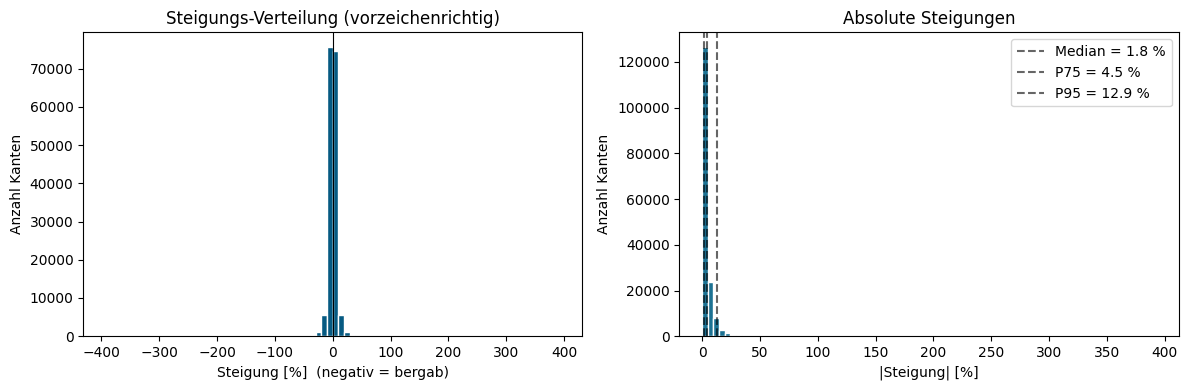

In [6]:
import numpy as np
import matplotlib.pyplot as plt

slopes_pct = [d['slope'] * 100 for _, _, _, d in G.edges(keys=True, data=True)
              if d.get('slope') is not None]

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].hist(slopes_pct, bins=80, color='#065A82', edgecolor='white')
axes[0].axvline(0, color='black', linewidth=0.8)
axes[0].set_xlabel('Steigung [%]  (negativ = bergab)')
axes[0].set_ylabel('Anzahl Kanten')
axes[0].set_title('Steigungs-Verteilung (vorzeichenrichtig)')

abs_slopes = np.abs(slopes_pct)
axes[1].hist(abs_slopes, bins=80, color='#1C7293', edgecolor='white')
for q, label in [(50, 'Median'), (75, 'P75'), (95, 'P95')]:
    val = np.percentile(abs_slopes, q)
    axes[1].axvline(val, color='black', linestyle='--', alpha=0.6,
                    label=f'{label} = {val:.1f} %')
axes[1].set_xlabel('|Steigung| [%]')
axes[1].set_ylabel('Anzahl Kanten')
axes[1].set_title('Absolute Steigungen')
axes[1].legend()

fig.tight_layout()
out = config.FIGURES_DIR / 'slope_histogram.png'
fig.savefig(out, dpi=180, bbox_inches='tight')
print('Gespeichert:', out)

## 7. Topografisch angereicherten Graph speichern

OSMnx serialisiert NetworkX-Graphen nach GraphML. Die Knoten- und Kanten-Attribute (inkl. `z`, `slope`) werden mit gespeichert.

In [7]:
out_path = config.PROCESSED_DIR / 'zh_walk_graph_topo.graphml'
ox.save_graphml(G, out_path)
print('Gespeichert:', out_path)

# Sanity-Check: laden, prüfen, dass z + slope in der Datei sind
G_check = ox.load_graphml(out_path)
first_node = next(iter(G_check.nodes))
first_edge = next(iter(G_check.edges(keys=True, data=True)))
print('Stichprobe Knoten:', first_node, '→ z =', G_check.nodes[first_node].get('z'))
print('Stichprobe Kante:', first_edge[0], '→', first_edge[1], 'slope =', first_edge[3].get('slope'))

Gespeichert: /Users/memissanir/Documents/Claude/Projects/Einsatz von Geodaten in Marketing/data/processed/zh_walk_graph_topo.graphml
Stichprobe Knoten: 453818 → z = 409.8860778808594
Stichprobe Kante: 453818 → 9822191179 slope = 0.012513978776362757


## 8. Zusammenfassung

- ✅ DEM SwissALTI3D ausgewertet (124 Kacheln zusammengeführt)
- ✅ Knoten-Höhen `z` gesetzt (gespeichert im Graph)
- ✅ Kanten-Steigungen `slope` als asymmetrische Werte gesetzt
- ✅ Topografischer Walk-Graph in `data/processed/zh_walk_graph_topo.graphml`

**Nächster Schritt** (Notebook 06b): Tobler-Walking-Geschwindigkeit pro Kante ableiten und einen netzwerkbasierten Score berechnen, der die Topografie berücksichtigt — anschliessend Δ-Vergleich zum flachen Score auf Quartier-Ebene.